# **Loading Libraries**

In [1]:
import pandas as pd
import numpy as np
import re
!pip install emoji
import emoji
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

print("Imports completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Imports completed.


# **Load data**

In [3]:
# Upload your CSV manually in Colab (Files → Upload)
df = pd.read_csv("/content/sample_data/comments.csv", encoding='latin1')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Comment,Label
0,"""As usual overacting of Anushka",cyberbullying
1,A classic example of what mental Illness looks...,cyberbullying
2,A unprofessional model and a professional model,cyberbullying
3,Actresses are to copy and paste,cyberbullying
4,After seeing Janhvi Kapoor... I m also thinkin...,cyberbullying


# **Preprocessing**

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove @mentions or #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Convert emojis to text meaning
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove special characters except emoji words
    text = re.sub(r'[^a-zA-Z0-9_ ]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization + stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words
    ]

    return " ".join(words)

df["cleaned_text"] = df["Comment"].apply(clean_text)

df[["Comment", "cleaned_text"]].head()

,Comment,cleaned_text
0,"""As usual overacting of Anushka",usual overacting anushka
1,A classic example of what mental Illness looks...,classic example mental illness look like
2,A unprofessional model and a professional model,unprofessional model professional model
3,Actresses are to copy and paste,actress copy paste
4,After seeing Janhvi Kapoor... I m also thinkin...,seeing janhvi kapoor also thinking b model nd ...


In [5]:
df["Label_cleaned"] = df["Label"].astype(str).str.strip().str.lower()
print("Unique labels after cleaning:", df["Label_cleaned"].unique())

df["Label"] = df["Label_cleaned"].map({
    "cyberbullying": 1,
    "not cyberbullying": 0
})

# Drop rows where 'Label' is NaN
df.dropna(subset=['Label'], inplace=True)

df["Label"].value_counts()

Unique labels after cleaning: ['cyberbullying' 'nan' 'not cyberbullying']


,count
Label,
1.0,500
0.0,500


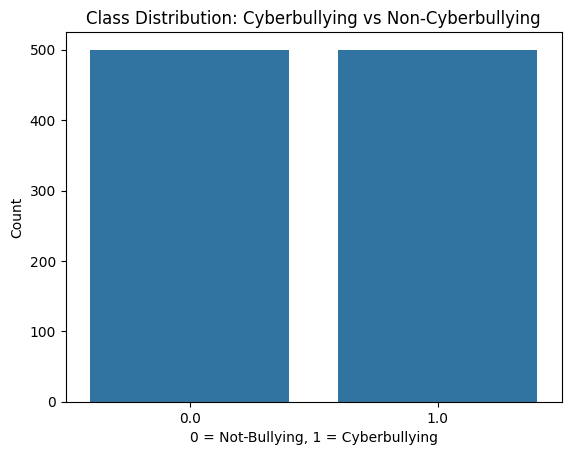

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Label", data=df)
plt.title("Class Distribution: Cyberbullying vs Non-Cyberbullying")
plt.xlabel("0 = Not-Bullying, 1 = Cyberbullying")
plt.ylabel("Count")
plt.show()


# **Feature extraction**

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df["cleaned_text"]
y = df["Label"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (1000, 5000)


# **Model training & evaluation**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Ready for Modeling!")


Data Ready for Modeling!


Logistic regression

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print(classification_report(y_test, y_pred_lr))


LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

         0.0       0.80      0.81      0.81       100
         1.0       0.81      0.80      0.80       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.80       200



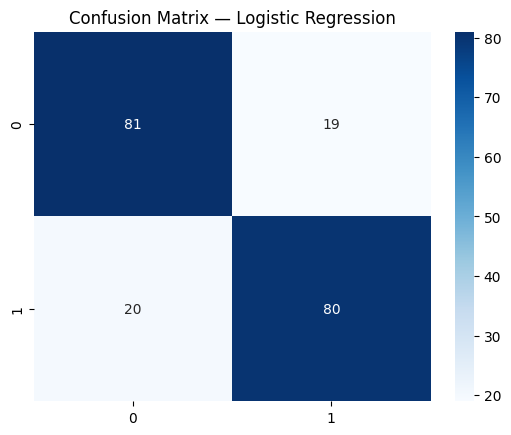

In [10]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


SVM

In [11]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("SVM RESULTS")
print(classification_report(y_test, y_pred_svm))


SVM RESULTS
              precision    recall  f1-score   support

         0.0       0.82      0.84      0.83       100
         1.0       0.84      0.82      0.83       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



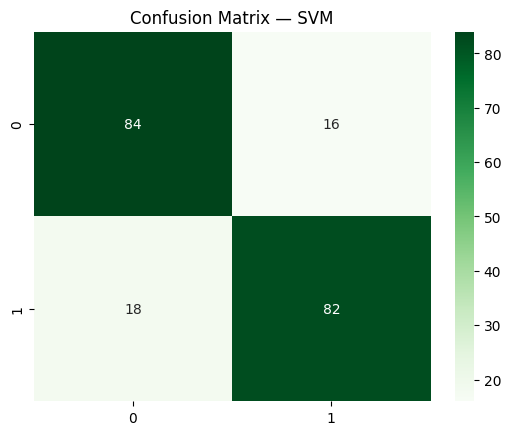

In [12]:
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix — SVM")
plt.show()


Naive bayes

In [13]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("NAIVE BAYES RESULTS")
print(classification_report(y_test, y_pred_nb))


NAIVE BAYES RESULTS
              precision    recall  f1-score   support

         0.0       0.74      0.89      0.81       100
         1.0       0.86      0.69      0.77       100

    accuracy                           0.79       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



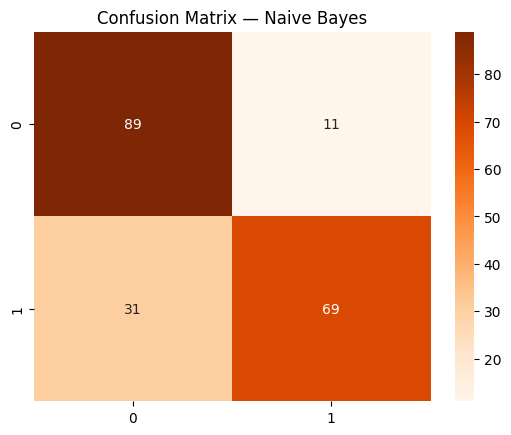

In [14]:
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix — Naive Bayes")
plt.show()


Random forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("RANDOM FOREST RESULTS")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

         0.0       0.87      0.68      0.76       100
         1.0       0.74      0.90      0.81       100

    accuracy                           0.79       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



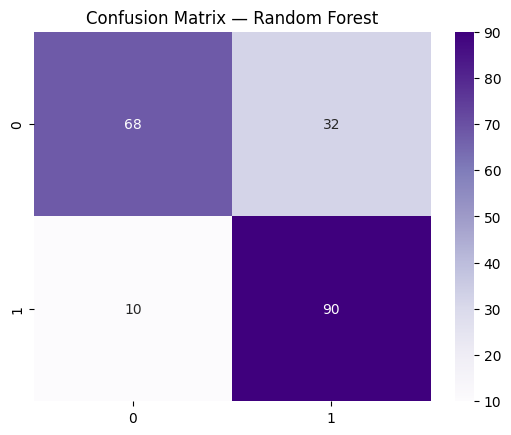

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix — Random Forest")
plt.show()


# Comparison report

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb,
    "Random Forest": y_pred_rf
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(results_df)


                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.805   0.808081    0.80  0.804020
1                  SVM     0.830   0.836735    0.82  0.828283
2          Naive Bayes     0.790   0.862500    0.69  0.766667
3        Random Forest     0.790   0.737705    0.90  0.810811


#**Model saving and testing**

In [18]:
import joblib

# Save the SVM model
joblib.dump(model_svm, "svm_model.pkl")

# Save the TF-IDF vectorizer also
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [19]:

model_svm = joblib.load("svm_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded!")


Model and vectorizer loaded!


In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r'[^a-zA-Z0-9_ ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words
    ]
    return " ".join(words)


In [21]:
def predict_comment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model_svm.predict(vectorized)[0]

    if prediction == 1:
        return "⚠️ Cyberbullying comment"
    else:
        return "✔️ Not cyberbullying comment"


In [22]:
user_text = input("Enter a comment to classify: ")

result = predict_comment(user_text)
print("\nPrediction:", result)


Enter a comment to classify: You are so dumb🤣🤣🤣

Prediction: ⚠️ Cyberbullying comment
